QUE 1 : How much Participetion happened in each and every year?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
df = pd.read_csv('/content/drive/MyDrive/Toronto_hourly_precipitation_1982_2023 Raw Data (1).csv')

In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 368160 entries, 0 to 368159
Data columns (total 24 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   name              368160 non-null  object 
 1   datetime          368160 non-null  object 
 2   temp              367874 non-null  float64
 3   feelslike         367874 non-null  float64
 4   dew               367874 non-null  float64
 5   humidity          367874 non-null  float64
 6   precip            367874 non-null  float64
 7   precipprob        367874 non-null  float64
 8   preciptype        34482 non-null   object 
 9   snow              166481 non-null  float64
 10  snowdepth         171436 non-null  float64
 11  windgust          85201 non-null   float64
 12  windspeed         367853 non-null  float64
 13  winddir           366040 non-null  float64
 14  sealevelpressure  367420 non-null  float64
 15  cloudcover        365716 non-null  float64
 16  visibility        36

In [4]:
print(df.head())

      name             datetime  temp  feelslike  dew  humidity  precip  \
0  L5B 1P2  1982-01-01T00:00:00   2.1       -3.5  2.0     99.64   0.000   
1  L5B 1P2  1982-01-01T01:00:00   2.1       -3.5  1.0     92.80   0.471   
2  L5B 1P2  1982-01-01T02:00:00   3.1       -2.1  2.0     92.91   0.000   
3  L5B 1P2  1982-01-01T03:00:00   3.1       -2.2  2.0     92.97   0.000   
4  L5B 1P2  1982-01-01T04:00:00   3.1       -2.2  2.0     92.92   0.000   

   precipprob preciptype  snow  ...  sealevelpressure  cloudcover  visibility  \
0         0.0        NaN   NaN  ...            1004.9       100.0         6.0   
1       100.0       rain   NaN  ...            1003.2       100.0         2.1   
2         0.0        NaN   NaN  ...            1002.7       100.0         5.1   
3         0.0        NaN   NaN  ...            1002.4       100.0         6.0   
4         0.0        NaN   NaN  ...            1001.7       100.0        13.0   

   solarradiation  solarenergy  uvindex  severerisk      condi

We need to convert data actual date and time format.

In [5]:
# Convert 'datetime' column to actual datetime format
df['datetime'] = pd.to_datetime(df['datetime'])

# Extract month and year as new columns
df['month'] = df['datetime'].dt.month
df['year'] = df['datetime'].dt.year

# Display first few rows to verify
print(df[['datetime', 'month', 'year']].head(20))
print(df[['datetime', 'month', 'year']].tail(20))


              datetime  month  year
0  1982-01-01 00:00:00      1  1982
1  1982-01-01 01:00:00      1  1982
2  1982-01-01 02:00:00      1  1982
3  1982-01-01 03:00:00      1  1982
4  1982-01-01 04:00:00      1  1982
5  1982-01-01 05:00:00      1  1982
6  1982-01-01 06:00:00      1  1982
7  1982-01-01 07:00:00      1  1982
8  1982-01-01 08:00:00      1  1982
9  1982-01-01 09:00:00      1  1982
10 1982-01-01 10:00:00      1  1982
11 1982-01-01 11:00:00      1  1982
12 1982-01-01 12:00:00      1  1982
13 1982-01-01 13:00:00      1  1982
14 1982-01-01 14:00:00      1  1982
15 1982-01-01 15:00:00      1  1982
16 1982-01-01 16:00:00      1  1982
17 1982-01-01 17:00:00      1  1982
18 1982-01-01 18:00:00      1  1982
19 1982-01-01 19:00:00      1  1982
                  datetime  month  year
368140 2023-12-31 04:00:00     12  2023
368141 2023-12-31 05:00:00     12  2023
368142 2023-12-31 06:00:00     12  2023
368143 2023-12-31 07:00:00     12  2023
368144 2023-12-31 08:00:00     12  2023
3681

Find Avg Toatal, Average and variance of precipitation

In [6]:
df['precip'] = pd.to_numeric(df['precip'], errors='coerce').fillna(0)

# Aggregate precipitation per month
monthly_precip = df.groupby('month')['precip'].agg(
    total_precipitation='sum',  # Total precipitation per month
    avg_precipitation='mean',   # Average hourly precipitation per month
    variance_precipitation='var' # Variance of precipitation per month
).reset_index()

# Display results
print(monthly_precip)


    month  total_precipitation  avg_precipitation  variance_precipitation
0       1             2400.159           0.076810                0.921762
1       2             2046.979           0.071915                0.417979
2       3             2135.749           0.068386                0.536466
3       4             2980.448           0.098641                0.828353
4       5             2922.082           0.093513                0.729567
5       6             3223.379           0.106593                1.370567
6       7             3297.146           0.105515                1.802214
7       8             3040.871           0.097314                1.205950
8       9             3125.795           0.103366                1.668176
9      10             2636.132           0.084294                0.597176
10     11             2724.826           0.090056                0.601366
11     12             2766.998           0.088550                1.594804


/tmp/ipython-input-1707742843.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=monthly_precip['month'], y=monthly_precip['total_precipitation'], palette="Blues_r")


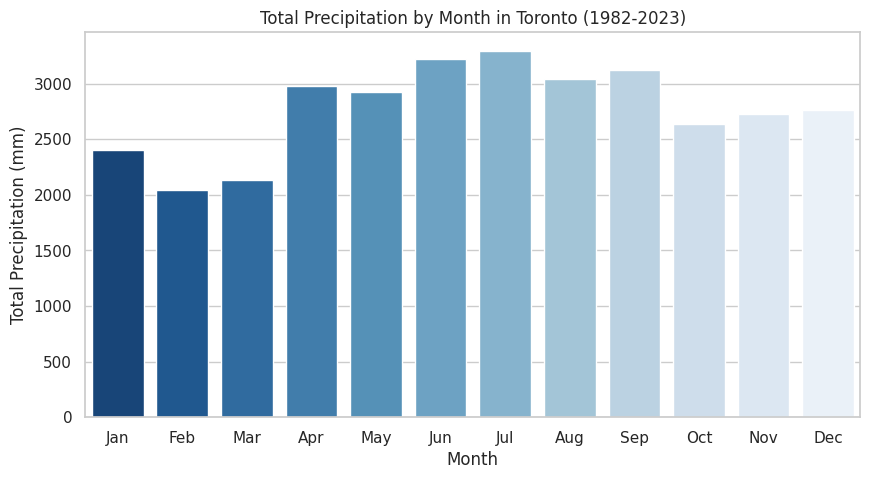

/tmp/ipython-input-1707742843.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df["month"], y=df["precip"], palette="coolwarm")


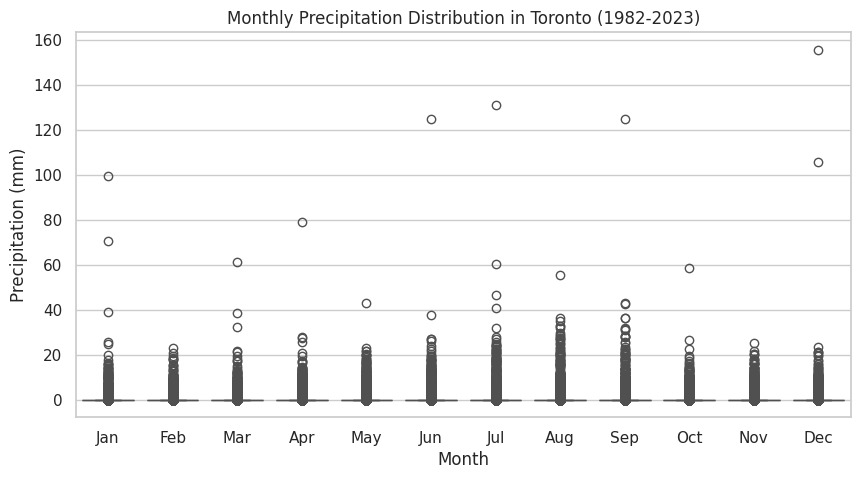

In [7]:
sns.set_theme(style="whitegrid")

# Create bar plot for total precipitation per month
plt.figure(figsize=(10, 5))
sns.barplot(x=monthly_precip['month'], y=monthly_precip['total_precipitation'], palette="Blues_r")
plt.xlabel("Month")
plt.ylabel("Total Precipitation (mm)")
plt.title("Total Precipitation by Month in Toronto (1982-2023)")
plt.xticks(range(12), ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
plt.show()

# Create box plot for precipitation distribution per month
plt.figure(figsize=(10, 5))
sns.boxplot(x=df["month"], y=df["precip"], palette="coolwarm")
plt.xlabel("Month")
plt.ylabel("Precipitation (mm)")
plt.title("Monthly Precipitation Distribution in Toronto (1982-2023)")
plt.xticks(range(12), ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
plt.show()

In [8]:
# Select relevant features for clustering (same as before)
features = ['total_precipitation', 'avg_precipitation', 'variance_precipitation']
scaler = StandardScaler()
monthly_precip_scaled = scaler.fit_transform(monthly_precip[features])

# Apply K-Means with k=5
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
monthly_precip['cluster'] = kmeans.fit_predict(monthly_precip_scaled)

# Sort clusters by mean total precipitation to assign meaningful labels
cluster_means = monthly_precip.groupby("cluster")["total_precipitation"].mean().sort_values()

# Create more granular labels based on precipitation levels
precip_levels = ["Very low", "Low", "Medium", "High", "Very High"]
cluster_mapping = {cluster: level for cluster, level in zip(cluster_means.index, precip_levels)}
monthly_precip['precip_category'] = monthly_precip['cluster'].map(cluster_mapping)

# Display clustered data
print(monthly_precip[['month', 'total_precipitation', 'precip_category']].sort_values('total_precipitation', ascending=False))

# Print cluster statistics
print("\nCluster Statistics:")
print(monthly_precip.groupby('precip_category')['total_precipitation'].describe())

    month  total_precipitation precip_category
6       7             3297.146       Very High
5       6             3223.379       Very High
8       9             3125.795       Very High
7       8             3040.871            High
3       4             2980.448            High
4       5             2922.082            High
11     12             2766.998          Medium
10     11             2724.826             Low
9      10             2636.132             Low
0       1             2400.159             Low
2       3             2135.749        Very low
1       2             2046.979        Very low

Cluster Statistics:
                 count         mean         std       min        25%  \
precip_category                                                        
High               3.0  2981.133667   59.397468  2922.082  2951.2650   
Low                3.0  2587.039000  167.808692  2400.159  2518.1455   
Medium             1.0  2766.998000         NaN  2766.998  2766.9980   
Very Hig

Now just implement hyperparameter tuning by taking value of K = 2 and K = 3

In [9]:
# Select relevant features for clustering (same as before)
features = ['total_precipitation', 'avg_precipitation', 'variance_precipitation']

# Standardize the features
scaler = StandardScaler()
monthly_precip_scaled = scaler.fit_transform(monthly_precip[features])

# Apply K-Means with k=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
monthly_precip['cluster'] = kmeans.fit_predict(monthly_precip_scaled)

# Sort clusters by mean total precipitation to assign meaningful labels
cluster_means = monthly_precip.groupby("cluster")["total_precipitation"].mean().sort_values()

# Create more granular labels based on precipitation levels
precip_levels = ["Very Low", "Low", "Medium", "High", "Very High"]
cluster_mapping = {cluster: level for cluster, level in zip(cluster_means.index, precip_levels)}
monthly_precip['precip_category'] = monthly_precip['cluster'].map(cluster_mapping)

# Display clustered data
print(monthly_precip[['month', 'total_precipitation', 'precip_category']].sort_values('total_precipitation', ascending=False))

# Print cluster statistics
print("\nCluster Statistics:")
print(monthly_precip.groupby('precip_category')['total_precipitation'].describe())

    month  total_precipitation precip_category
6       7             3297.146          Medium
5       6             3223.379          Medium
8       9             3125.795          Medium
7       8             3040.871          Medium
3       4             2980.448             Low
4       5             2922.082             Low
11     12             2766.998          Medium
10     11             2724.826             Low
9      10             2636.132             Low
0       1             2400.159        Very Low
2       3             2135.749        Very Low
1       2             2046.979        Very Low

Cluster Statistics:
                 count         mean         std       min        25%  \
precip_category                                                        
Low                4.0  2815.872000  162.236109  2636.132  2702.6525   
Medium             5.0  3090.837800  205.378398  2766.998  3040.8710   
Very Low           3.0  2194.295667  183.724827  2046.979  2091.3640   

       

In [10]:
# Select relevant features for clustering (same as before)
features = ['total_precipitation', 'avg_precipitation', 'variance_precipitation']

# Standardize the features
scaler = StandardScaler()
monthly_precip_scaled = scaler.fit_transform(monthly_precip[features])

# Apply K-Means with k=2
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
monthly_precip['cluster'] = kmeans.fit_predict(monthly_precip_scaled)

# Sort clusters by mean total precipitation to assign meaningful labels
cluster_means = monthly_precip.groupby("cluster")["total_precipitation"].mean().sort_values()

# Create more granular labels based on precipitation levels
precip_levels = ["Very Low", "Low", "Medium", "High", "Very High"]
cluster_mapping = {cluster: level for cluster, level in zip(cluster_means.index, precip_levels)}
monthly_precip['precip_category'] = monthly_precip['cluster'].map(cluster_mapping)

# Display clustered data
print(monthly_precip[['month', 'total_precipitation', 'precip_category']].sort_values('total_precipitation', ascending=False))
print("\nCluster Statistics:")
print(monthly_precip.groupby('precip_category')['total_precipitation'].describe())

    month  total_precipitation precip_category
6       7             3297.146             Low
5       6             3223.379             Low
8       9             3125.795             Low
7       8             3040.871             Low
3       4             2980.448             Low
4       5             2922.082             Low
11     12             2766.998             Low
10     11             2724.826        Very Low
9      10             2636.132        Very Low
0       1             2400.159        Very Low
2       3             2135.749        Very Low
1       2             2046.979        Very Low

Cluster Statistics:
                 count         mean         std       min       25%       50%  \
precip_category                                                                 
Low                7.0  3050.959857  181.775421  2766.998  2951.265  3040.871   
Very Low           5.0  2388.769000  297.947989  2046.979  2135.749  2400.159   

                      75%       max  
preci

According to KNN result of this question is on and average Mid time of year has most rainy months as compared to begin and enf of the year months in Toronto

This silhouette score shows the accuracy. Lower the score Higher the accurecy and in this case model score is 0.461.

In [11]:
from sklearn.metrics import silhouette_score
sil_score = silhouette_score(monthly_precip_scaled, monthly_precip['cluster'])
print(f"Silhouette Score: {sil_score:.3f}")

Silhouette Score: 0.461


Question 2 : Has there been an increase in extreme precipitation events over the years?


In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression  # Better for classification
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                            f1_score, roc_auc_score, confusion_matrix,
                            RocCurveDisplay, PrecisionRecallDisplay)

# Load and prepare data
df = pd.read_csv('/content/drive/MyDrive/Toronto_hourly_precipitation_1982_2023 Raw Data (1).csv',
                 parse_dates=['datetime'])
df['year'] = df['datetime'].dt.year

# Feature Engineering
df['temp_change'] = df['temp'].diff(1)  # 1-hour temperature delta
df['pressure_change'] = df['sealevelpressure'].diff(1)

# Define extreme precipitation (top 5% of hourly values)
extreme_threshold = df['precip'].quantile(0.95)
df['extreme_precip'] = (df['precip'] >= extreme_threshold).astype(int)

# Select relevant features
features = [
    'temp',
    'temp_change',
    'humidity',
    'windspeed',
    'sealevelpressure',
    'pressure_change',
    'cloudcover',
    'precipprob'
]

Need to do some data cleaning. Based on question we need to remove null values.

In [13]:
# Handle missing values
df[features] = df[features].fillna(df[features].median())

# Normalize features (MinMax for probabilistic interpretation)
scaler = MinMaxScaler()
X = scaler.fit_transform(df[features])
y = df['extreme_precip']

# Split data (stratified to preserve class imbalance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Now implement the logistic regression as our data is binary so it is very good approch to use logistic regression

In [14]:
# Use Logistic Regression (because of binary classification)
model = LogisticRegression(class_weight='balanced', max_iter=1000)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]  # Probabilities for AUC

Model Performance
Accuracy: 0.983
Precision: 0.744
Recall: 0.993
F1 Score: 0.851
ROC AUC: 0.993


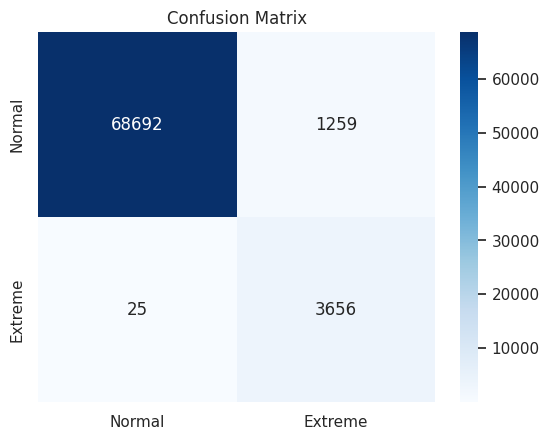

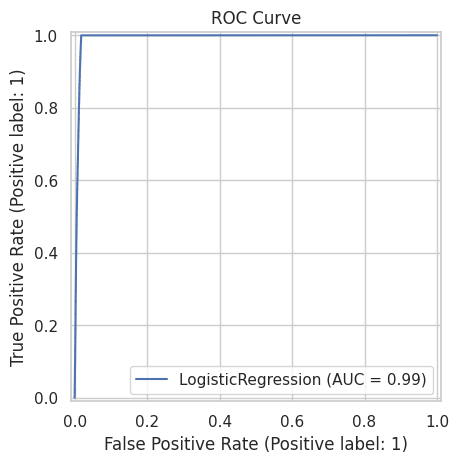

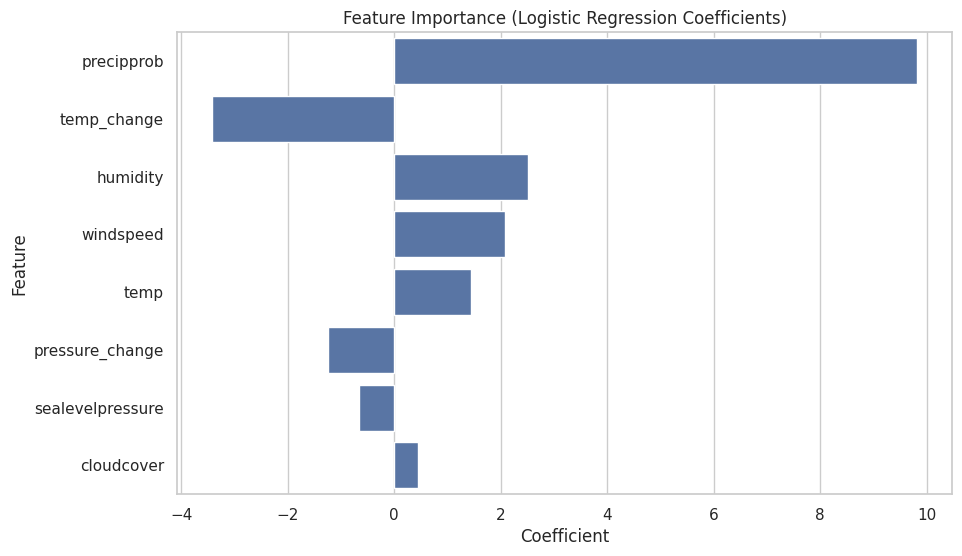

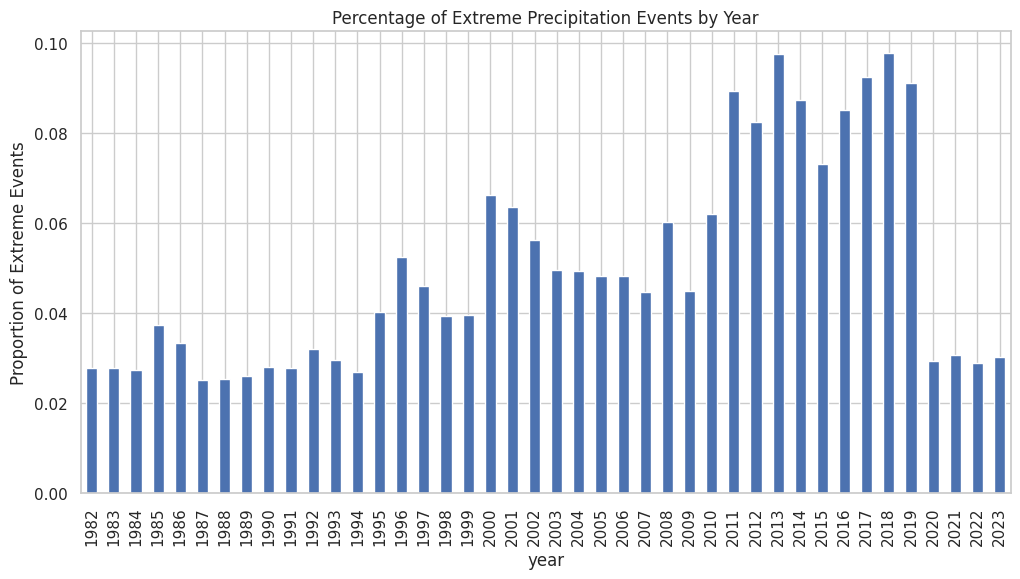

In [15]:
# Evaluation Metrics
print("Model Performance")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(f"Precision: {precision_score(y_test, y_pred):.3f}")
print(f"Recall: {recall_score(y_test, y_pred):.3f}")
print(f"F1 Score: {f1_score(y_test, y_pred):.3f}")
print(f"ROC AUC: {roc_auc_score(y_test, y_prob):.3f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Extreme'],
            yticklabels=['Normal', 'Extreme'])
plt.title("Confusion Matrix")
plt.show()

# ROC Curve
RocCurveDisplay.from_estimator(model, X_test, y_test)
plt.title("ROC Curve")
plt.show()

# Feature Importance
importance = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=importance)
plt.title("Feature Importance (Logistic Regression Coefficients)")
plt.show()

# Trend Analysis (Extreme Events Over Time)
plt.figure(figsize=(12, 6))
df.groupby('year')['extreme_precip'].mean().plot(kind='bar')
plt.title("Percentage of Extreme Precipitation Events by Year")
plt.ylabel("Proportion of Extreme Events")
plt.show()

Accuracy: 0.983 Precision: 0.744 Recall: 0.993 F1 Score: 0.851 ROC AUC: 0.993

SO this logistic regression gave us above accuracy result which denoted that model is train on good scale

Que 3:How does hourly precipitation correlate with temperature changes?

So, Here we are going to use MLR(MULTIPLE LINEAR REGRESSION) and need to add some feature

In [16]:
file_path = "/content/drive/MyDrive/Toronto_hourly_precipitation_1982_2023 Raw Data (1).csv"
df = pd.read_csv(file_path, parse_dates=['datetime'])

# Drop rows with missing values in critical columns
df = df.dropna(subset=[
    'temp', 'precip', 'humidity', 'dew',
    'windspeed', 'cloudcover', 'visibility', 'solarradiation'
])

# Feature engineering
df['temp_change'] = df['temp'].diff()
df = df.dropna()  # Drop first row with NaN in temp_change

# Define features and target
features = [
    'temp', 'temp_change', 'humidity', 'dew',
    'windspeed', 'cloudcover', 'visibility', 'solarradiation'
]
X = df[features]
y = df['precip']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,
    stratify=(y > 0).astype(int)  # Handle imbalance
)


After defining feature, let's implement MLR and RMSE(Root mean squre error) and R2 for accuracy. According to accuracy matrix, It is shows that model train very well

In [17]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train MLR model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Predict
y_pred = model.predict(X_test_scaled)

# Evaluation
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
X_test_scaled = scaler.transform(X_test)

# Train MLR model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Predict
y_pred = model.predict(X_test_scaled)

# Evaluation
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

# Print RMSE and R²
print(f"rmse: {rmse:.3f}")
print(f"r2: {r2:.3f}")


rmse: 1.746
r2: 0.028


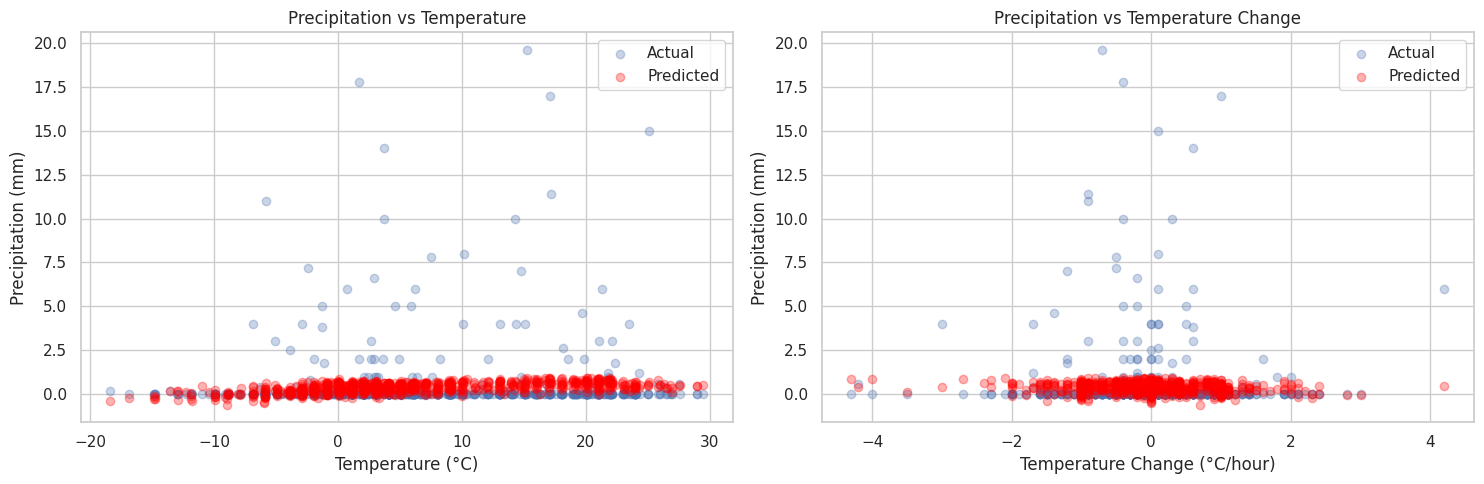

In [18]:
rmse
r2

# Visualizations
plt.figure(figsize=(15, 5))

# Plot 1: Temperature vs Precipitation
plt.subplot(1, 2, 1)
plt.scatter(X_test['temp'], y_test, alpha=0.3, label='Actual')
plt.scatter(X_test['temp'], y_pred, alpha=0.3, color='red', label='Predicted')
plt.xlabel('Temperature (°C)')
plt.ylabel('Precipitation (mm)')
plt.title('Precipitation vs Temperature')
plt.legend()

# Plot 2: Temperature Change vs Precipitation
plt.subplot(1, 2, 2)
plt.scatter(X_test['temp_change'], y_test, alpha=0.3, label='Actual')
plt.scatter(X_test['temp_change'], y_pred, alpha=0.3, color='red', label='Predicted')
plt.xlabel('Temperature Change (°C/hour)')
plt.ylabel('Precipitation (mm)')
plt.title('Precipitation vs Temperature Change')
plt.legend()

plt.tight_layout()
plt.show()

In [19]:
# Correlation Analysis
print("\nCorrelation Matrix:")
print(df[['precip', 'temp', 'temp_change']].corr())

# Conditional Analysis (e.g., different behavior when warming vs cooling)
print("\nPrecipitation during warming vs cooling periods:")
print(f"Mean precip when warming (ΔT > 0): {df[df['temp_change'] > 0]['precip'].mean():.4f} mm")
print(f"Mean precip when cooling (ΔT < 0): {df[df['temp_change'] < 0]['precip'].mean():.4f} mm")


Correlation Matrix:
               precip      temp  temp_change
precip       1.000000  0.072807    -0.026891
temp         0.072807  1.000000     0.003736
temp_change -0.026891  0.003736     1.000000

Precipitation during warming vs cooling periods:
Mean precip when warming (ΔT > 0): 0.4231 mm
Mean precip when cooling (ΔT < 0): 0.5089 mm
